# PhishGuard AI — Shakkya Sanketh (CIT-24-01-0573)
## NLP Pipeline — Phishing Email Detection
### Models: SVM (ML) | BiLSTM + Attention (DL)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")
print(f"Pandas:  {pd.__version__}")
print(f"Numpy:   {np.__version__}")

✅ All libraries imported!
Pandas:  3.0.3
Numpy:   2.4.4


In [3]:
# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('../data/phishing_email.csv')

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded successfully!

Shape: (82486, 2)
Columns: ['text_combined', 'label']


In [4]:
# ── Initial Exploration ───────────────────────────────────────
print("First 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nPhishing:   {df[df['label']==1].shape[0]:,}")
print(f"Legitimate: {df[df['label']==0].shape[0]:,}")

First 5 rows:


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0



Data Types:
text_combined      str
label            int64
dtype: object

Missing Values:
text_combined    0
label            0
dtype: int64

Class Distribution:
label
1    42891
0    39595
Name: count, dtype: int64

Phishing:   42,891
Legitimate: 39,595


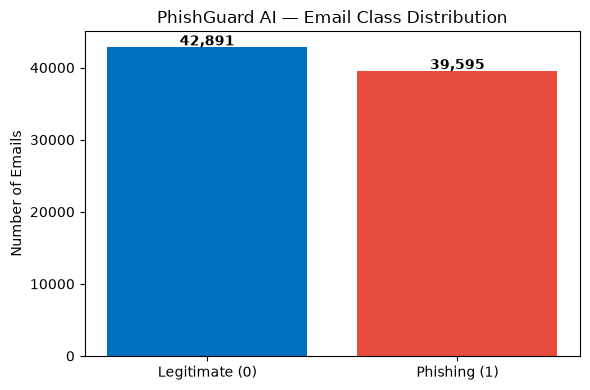

Chart saved to screenshots folder!


In [5]:
# ── Class Distribution Chart ──────────────────────────────────
plt.figure(figsize=(6, 4))
counts = df['label'].value_counts()
plt.bar(['Legitimate (0)', 'Phishing (1)'], 
        counts.values, 
        color=['#0070C0', '#E74C3C'])
plt.title('PhishGuard AI — Email Class Distribution')
plt.ylabel('Number of Emails')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150)
plt.show()
print("Chart saved to screenshots folder!")

In [6]:
# Check actual column names
print(df.columns.tolist())
print(df.head())

['text_combined', 'label']
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0
3  hpl nom may 30 2001 see attached file hplno 53...      0
4  hpl nom june 1 2001 see attached file hplno 60...      0


In [7]:
# ── Language Detection ──────────────────────────────────────
from langdetect import detect, DetectorFactory
from collections import Counter
import matplotlib.pyplot as plt

DetectorFactory.seed = 0  # makes results reproducible

def safe_detect(text):
    """Detect language, return 'unknown' if detection fails."""
    try:
        if len(str(text).strip()) < 10:  # too short to detect reliably
            return 'unknown'
        return detect(str(text))
    except:
        return 'unknown'

# Run on a SAMPLE first (full dataset takes too long ~82,500 rows)
sample_size = 2000
sample_df = df.sample(n=sample_size, random_state=42)

print(f"Detecting languages on {sample_size} sample emails...")
sample_df['language'] = sample_df['text_combined'].apply(safe_detect)
print("Done!")

# Count languages
lang_counts = sample_df['language'].value_counts()
print("\nLanguage Distribution (from sample):")
print(lang_counts)

Detecting languages on 2000 sample emails...
Done!

Language Distribution (from sample):
language
en    1959
fr       6
nl       6
ca       5
de       4
es       4
et       3
tr       3
pt       2
no       2
cy       1
it       1
sq       1
ro       1
da       1
pl       1
Name: count, dtype: int64


In [8]:
# ── Full Dataset Language Detection — Split by Class ──────────
from langdetect import detect, DetectorFactory
from tqdm import tqdm
import pandas as pd

DetectorFactory.seed = 0
tqdm.pandas()  # enables progress bar with pandas apply

def safe_detect(text):
    try:
        if len(str(text).strip()) < 10:
            return 'unknown'
        return detect(str(text))
    except:
        return 'unknown'

print(f"Running language detection on ALL {len(df):,} emails...")
print("This will take approximately 10-15 minutes. Please wait...")

df['language'] = df['text_combined'].progress_apply(safe_detect)

print("\nDone! Language column added to dataframe.")

Running language detection on ALL 82,486 emails...
This will take approximately 10-15 minutes. Please wait...


100%|██████████| 82486/82486 [06:13<00:00, 220.88it/s]


Done! Language column added to dataframe.


In [9]:
# ── Language Distribution — Phishing vs Legitimate ────────────
phishing_langs   = df[df['label'] == 1]['language'].value_counts()
legitimate_langs = df[df['label'] == 0]['language'].value_counts()

print("=" * 50)
print("LEGITIMATE EMAILS — Language Distribution")
print("=" * 50)
print(legitimate_langs)
print(f"\nTotal Legitimate: {df[df['label']==0].shape[0]:,}")

print("\n" + "=" * 50)
print("PHISHING EMAILS — Language Distribution")
print("=" * 50)
print(phishing_langs)
print(f"\nTotal Phishing: {df[df['label']==1].shape[0]:,}")

LEGITIMATE EMAILS — Language Distribution
language
en    38994
fr      160
ca       94
nl       82
et       38
it       32
pl       29
de       25
sv       24
af       22
es       21
da       20
no       12
pt       10
ro        7
so        6
fi        5
cy        3
sl        3
sk        2
sw        2
id        2
cs        1
lv        1
Name: count, dtype: int64

Total Legitimate: 39,595

PHISHING EMAILS — Language Distribution
language
en         41763
fr           168
ca           142
es           141
nl           129
pt            88
de            66
pl            63
it            49
cy            42
no            37
tr            23
da            22
af            21
ro            19
sv            18
id            16
et            13
so            10
sl             9
cs             8
unknown        7
tl             7
hr             5
sq             3
sk             3
bg             3
ja             3
fi             2
lt             2
ru             2
ar             2
he             

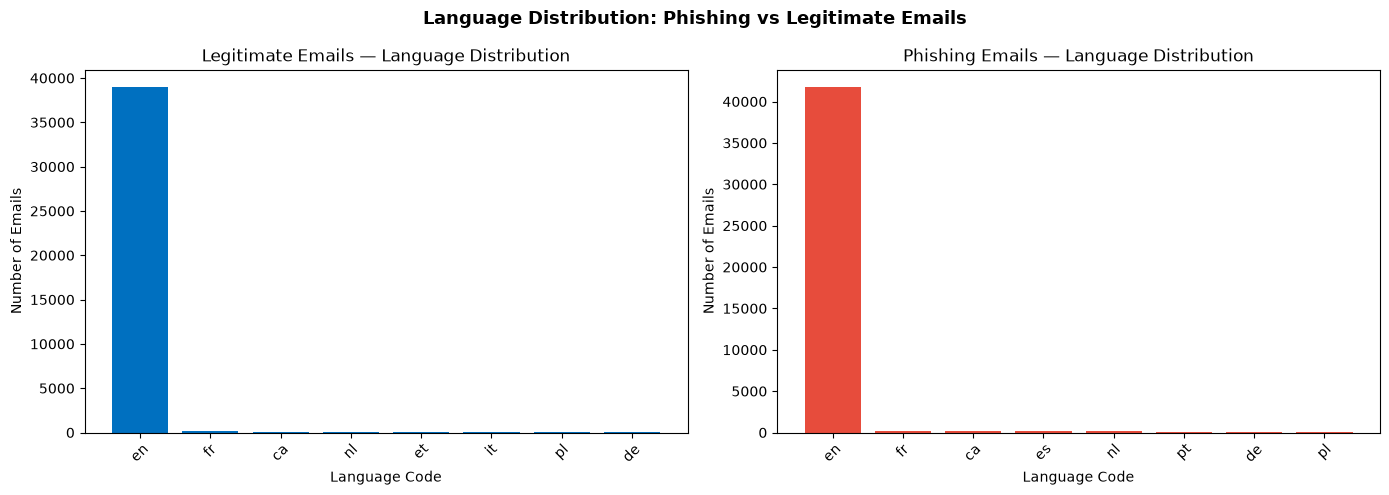

Chart saved to screenshots folder!


In [10]:
# ── Visualization — Side by Side Comparison ───────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 8 languages only (others get grouped)
top_legit = legitimate_langs.head(8)
top_phish = phishing_langs.head(8)

axes[0].bar(top_legit.index, top_legit.values, color='#0070C0')
axes[0].set_title('Legitimate Emails — Language Distribution')
axes[0].set_xlabel('Language Code')
axes[0].set_ylabel('Number of Emails')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(top_phish.index, top_phish.values, color='#E74C3C')
axes[1].set_title('Phishing Emails — Language Distribution')
axes[1].set_xlabel('Language Code')
axes[1].set_ylabel('Number of Emails')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Language Distribution: Phishing vs Legitimate Emails', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/language_distribution_by_class.png', dpi=150)
plt.show()

print("Chart saved to screenshots folder!")

In [11]:
# Save dataframe with language column for future use
df.to_csv('../data/phishing_email_with_language.csv', index=False)
print("Saved! You can load this file directly next time instead of re-detecting languages.")

Saved! You can load this file directly next time instead of re-detecting languages.


In [12]:
# Filter dataset to English-only emails
# Rationale: severe class imbalance across non-English languages would introduce
# learning artifacts rather than genuine signal (see language_distribution_by_class chart)

print(f"Total emails before filtering: {len(df)}")
print(f"Language distribution before filtering:\n{df['language'].value_counts()}\n")

df_en = df[df['language'] == 'en'].reset_index(drop=True)

print(f"Total emails after filtering to English only: {len(df_en)}")
print(f"Removed: {len(df) - len(df_en)} non-English emails")

# Check class balance after filtering — this matters since dropping rows
# can shift the phishing/legit ratio
print(f"\nClass distribution after English filtering:\n{df_en['label'].value_counts()}")
print(f"Class balance: {df_en['label'].value_counts(normalize=True)}")

# Save the filtered dataset so teammates can use it directly too
df_en.to_csv('../data/phishing_email_english_only.csv', index=False)
print("\nSaved filtered dataset to data/phishing_email_english_only.csv")

Total emails before filtering: 82486
Language distribution before filtering:
language
en         80757
fr           328
ca           236
nl           211
es           162
pt            98
pl            92
de            91
it            81
et            51
no            49
cy            45
af            43
sv            42
da            42
ro            26
tr            23
id            18
so            16
sl            12
cs             9
unknown        7
fi             7
tl             7
sk             5
hr             5
sq             3
sw             3
bg             3
ja             3
lt             2
ru             2
ar             2
he             2
lv             1
hu             1
uk             1
Name: count, dtype: int64

Total emails after filtering to English only: 80757
Removed: 1729 non-English emails

Class distribution after English filtering:
label
1    41763
0    38994
Name: count, dtype: int64
Class balance: label
1    0.517144
0    0.482856
Name: proportion, dtype: 

In [13]:
# ── Text Preprocessing — Phishing Email Detection ──────────────────────
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

URL_PATTERN = re.compile(r'(https?://\S+|www\.\S+)')
EMAIL_PATTERN = re.compile(r'\S+@\S+\.\S+')


def extract_signal_features(text):
    """Extract phishing-relevant signal features BEFORE cleaning destroys them."""
    text = str(text)
    return {
        'url_count': len(URL_PATTERN.findall(text)),
        'exclamation_count': text.count('!'),
        'caps_word_count': len(re.findall(r'\b[A-Z]{3,}\b', text)),
        'caps_ratio': (sum(1 for c in text if c.isupper()) / len(text)) if len(text) > 0 else 0,
        'char_length': len(text),
    }


def light_clean(text):
    """Replace URLs/emails with tokens, normalize whitespace. Preserves caps, punctuation."""
    text = str(text)
    text = URL_PATTERN.sub('URLTOKEN', text)
    text = EMAIL_PATTERN.sub('EMAILTOKEN', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def deep_clean(text):
    """Full NLP cleaning for TF-IDF/SVM: lowercase, remove punctuation/numbers,
    remove stopwords, lemmatize."""
    text = light_clean(text)
    text = text.lower()
    text = re.sub(r'urltoken', ' urltoken ', text)
    text = re.sub(r'emailtoken', ' emailtoken ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)  # strip numbers/punctuation
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)


print("Extracting signal features...")
signal_features = df_en['text_combined'].progress_apply(extract_signal_features).apply(pd.Series)
df_en = pd.concat([df_en, signal_features], axis=1)

print("Applying light cleaning (for BiLSTM tokenizer)...")
df_en['text_light_clean'] = df_en['text_combined'].progress_apply(light_clean)

print("Applying deep cleaning (for TF-IDF/SVM)...")
df_en['text_deep_clean'] = df_en['text_combined'].progress_apply(deep_clean)

print("\nDone! Sample comparison:")
print(f"\nOriginal:\n{df_en['text_combined'].iloc[0][:200]}")
print(f"\nLight clean:\n{df_en['text_light_clean'].iloc[0][:200]}")
print(f"\nDeep clean:\n{df_en['text_deep_clean'].iloc[0][:200]}")

# Checkpoint save
df_en.to_csv('../data/phishing_email_preprocessed.csv', index=False)
print("\nSaved checkpoint to data/phishing_email_preprocessed.csv")

Extracting signal features...


100%|██████████| 80757/80757 [00:03<00:00, 20538.02it/s]


Applying light cleaning (for BiLSTM tokenizer)...


100%|██████████| 80757/80757 [00:10<00:00, 7389.45it/s] 


Applying deep cleaning (for TF-IDF/SVM)...


100%|██████████| 80757/80757 [00:50<00:00, 1597.63it/s]



Done! Sample comparison:

Original:
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

Light clean:
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

Deep clean:
hpl nom may see attached file hplno xl hplno xl

Saved checkpoint to data/phishing_email_preprocessed.csv
